**Scrapping Aplikasi Google (H&M)**

by Mirza Fathi Taufiqurrahman
5026231105

**Instalasi Awal**

In [3]:
!pip install google-play-scraper
!pip install nltk
!pip install sastrawi
!pip install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


**Collecting Data**

In [4]:
from google_play_scraper import Sort, reviews_all
import pandas as pd

app_id = 'com.hm.gillcaptital'

result = reviews_all(
    app_id,
    sleep_milliseconds=1000,
    lang='id',
    country='id',
    sort=Sort.NEWEST
)

df = pd.DataFrame(result)

file_name = "semua_ulasan_hm.csv"
df.to_csv(file_name, index=False)

**Text Pre-Processing**

Stopwords

In [5]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

nltk.download('stopwords')
indonesian_stopwords = set(stopwords.words('indonesian'))

text_column = 'content'

all_text = ' '.join(df[text_column].dropna().astype(str))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
df.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,apk lemot bgt buset,1,0,21.3.5-PROD,2026-03-05 01:07:34,None,None
1,lu mau internet sekencang apa?,1,0,21.3.5-PROD,2026-03-04 14:48:04,None,None
2,"barangnya pas dihati , harga nya pas di dompet",5,1,21.2.1-PROD,2026-03-04 10:24:31,None,None
3,"kenapa susah mau mau isi tanggal lahir juga, a...",3,0,21.3.1-PROD,2026-02-10 03:57:38,None,None
4,mantap..,5,0,None,2026-02-07 04:46:36,None,None
...,...,...,...,...,...,...,...
2025,Lemod dan tergembel gabisa di akses setelahh d...,1,10,0.0.3,2019-11-19 13:53:37,None,None
2026,Lemot bgt parahh,3,10,0.0.3,2019-10-04 21:17:57,None,None
2027,Kok gabisa cek orderan ya?,2,46,0.0.3,2019-09-26 11:44:17,None,None
2028,Mantap,5,6,None,2019-09-25 16:39:19,None,None


Stopwords Removal

In [9]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get Indonesian stopwords
indonesian_stopwords = stopwords.words('indonesian')

# Add custom stopwords
custom_stopwords = ['ga', 'gak', 'ya', 'it', 'dr', 'nya', 'bgt', 'udh', 'yg', 'aja', 'lg', 'sdh', 'tp', 'klo', 'gk', 'udah', 'trs']
indonesian_stopwords.extend(custom_stopwords)

# Display first 20 stopwords
print(indonesian_stopwords[:20])
print(len(indonesian_stopwords))

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']
775


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
indonesian_stopwords

['ada',
 'adalah',
 'adanya',
 'adapun',
 'agak',
 'agaknya',
 'agar',
 'akan',
 'akankah',
 'akhir',
 'akhiri',
 'akhirnya',
 'aku',
 'akulah',
 'amat',
 'amatlah',
 'anda',
 'andalah',
 'antar',
 'antara',
 'antaranya',
 'apa',
 'apaan',
 'apabila',
 'apakah',
 'apalagi',
 'apatah',
 'artinya',
 'asal',
 'asalkan',
 'atas',
 'atau',
 'ataukah',
 'ataupun',
 'awal',
 'awalnya',
 'bagai',
 'bagaikan',
 'bagaimana',
 'bagaimanakah',
 'bagaimanapun',
 'bagi',
 'bagian',
 'bahkan',
 'bahwa',
 'bahwasanya',
 'baik',
 'bakal',
 'bakalan',
 'balik',
 'banyak',
 'bapak',
 'baru',
 'bawah',
 'beberapa',
 'begini',
 'beginian',
 'beginikah',
 'beginilah',
 'begitu',
 'begitukah',
 'begitulah',
 'begitupun',
 'bekerja',
 'belakang',
 'belakangan',
 'belum',
 'belumlah',
 'benar',
 'benarkah',
 'benarlah',
 'berada',
 'berakhir',
 'berakhirlah',
 'berakhirnya',
 'berapa',
 'berapakah',
 'berapalah',
 'berapapun',
 'berarti',
 'berawal',
 'berbagai',
 'berdatangan',
 'beri',
 'berikan',
 'berikut'

,Word,Frequency
0,aplikasi,263
1,lemot,194
2,bagus,158
3,barang,127
4,good,126
...,...,...
95,bahasa,18
96,d,18
97,"lemot,",18
98,mudah,18


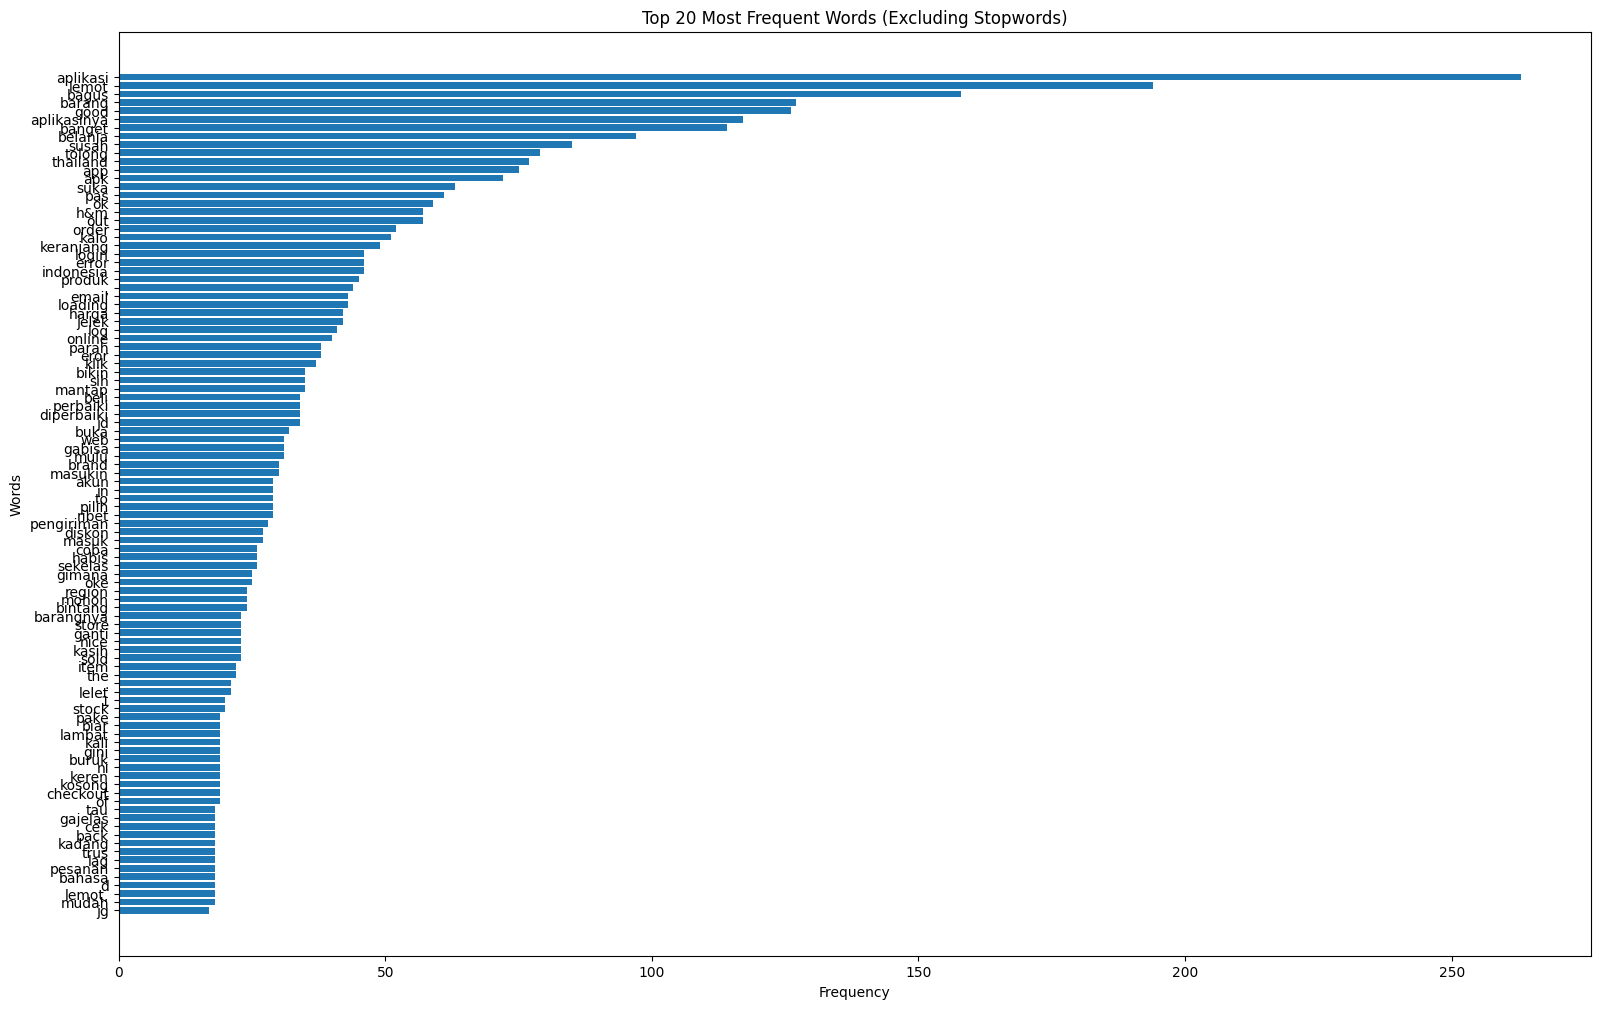

In [10]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

text_column = 'content'

all_text = ' '.join(df[text_column].dropna().astype(str))

words = all_text.split()
filtered_words = [word.lower() for word in words if word.lower() not in indonesian_stopwords]

word_counts = Counter(filtered_words)
common_words = word_counts.most_common(100)

word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Display the most common words
display(word_freq_df)

# Plot the frequent words
plt.figure(figsize=(19, 12))
plt.barh(word_freq_df['Word'][::-1], word_freq_df['Frequency'][::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words (Excluding Stopwords)")
plt.show()

**Summary Analysis**

**Visualisasi**

**Final**